# Operations Research & Network Analysis
## EV Charging Station Network — VRP, MIP, LPP, DEA, Graph Analysis

---

This notebook applies a suite of **Operations Research (OR)** and **network-science** methods  
to the ST-EVCDP Shenzhen EV-charging network:

| Section | Method | Purpose |
|---------|---------|---------|
| §1 | Data Loading & Feature Engineering | Unified station-level KPIs |
| §2 | Linear Programming (LPP) | Revenue-maximising tariff allocation |
| §3 | Mixed-Integer Programming (MIP) | Binary charger-activation scheduling |
| §4 | Vehicle Routing Problem (VRP) | Optimal service-vehicle dispatch |
| §5 | Graph Analysis | MST, centrality, shortest paths |
| §6 | Data Envelopment Analysis (DEA) | Station efficiency scores |
| §7 | Network Visualisations | All results on the spatial graph |

> **Data paths** — update `DATA_DIR` once before running all cells.

---
## 0. Setup & Imports

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import seaborn as sns
import networkx as nx
from scipy import optimize
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.spatial.distance import cdist

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'
SEED = 42
np.random.seed(SEED)

# ── PATH CONFIGURATION ────────────────────────────────────────────────────────
# Set DATA_DIR to the folder that contains both sub-folders, or '' if running
# from the same directory.
import os
DATA_DIR = 'C:/Users/pragy/Downloads/Analytics_Summer_projects_2026/EV_dynamic_pricing_socbiz'
def p(fname): return os.path.join(DATA_DIR, fname)

print('Setup complete.')


Setup complete.


---
## 1. Data Loading

In [5]:
# ── ACN-Data ─────────────────────────────────────────────────────────────────
acn_raw = pd.read_excel(p(DATA_DIR + '/ACN Data_ 25 April 2018 to 16 Dec 2018/acndata_sessions.json.xlsx'))

# ── ST-EVCDP ─────────────────────────────────────────────────────────────────
time_df      = pd.read_csv(p(DATA_DIR + '/UrbanEV_ SZ_districts/time.csv'))
duration_df  = pd.read_csv(p(DATA_DIR + '/UrbanEV_ SZ_districts/duration.csv'))
volume_df    = pd.read_csv(p(DATA_DIR + '/UrbanEV_ SZ_districts/volume.csv'))     # kWh delivered per 5-min slot
adj_df       = pd.read_csv(p(DATA_DIR + '/UrbanEV_ SZ_districts/adj.csv'))        # binary adjacency matrix
distance_df  = pd.read_csv(p(DATA_DIR + '/UrbanEV_ SZ_districts/distance.csv'))   # km inter-station distances
info_df      = pd.read_csv(p(DATA_DIR + '/UrbanEV_ SZ_districts/information.csv'))# station metadata
occupancy_df = pd.read_csv(p(DATA_DIR + '/UrbanEV_ SZ_districts/occupancy.csv'))  # busy piles count
price_df     = pd.read_csv(p(DATA_DIR + '/UrbanEV_ SZ_districts/price.csv'))      # ¥/kWh
stations_df  = pd.read_csv(p(DATA_DIR + '/UrbanEV_ SZ_districts/stations.csv'))

print('ACN raw:      ', acn_raw.shape)
print('ST-EVCDP occupancy:', occupancy_df.shape, '| volume:', volume_df.shape)
print('Info (247 districts):', info_df.shape)


ACN raw:       (16304, 27)
ST-EVCDP occupancy: (8640, 248) | volume: (8640, 248)
Info (247 districts): (247, 10)


---
## 2. Feature Engineering — Station-Level KPIs

In [6]:
# ── Station IDs from info ────────────────────────────────────────────────────
station_ids = info_df['grid'].astype(str).tolist()

# ── Occupancy & volume matrices (rows = timesteps, cols = stations) ───────────
occ_mat  = occupancy_df[station_ids].values.astype(float)
vol_mat  = volume_df[station_ids].values.astype(float)
price_mat = price_df[station_ids].values.astype(float)

pile_counts = info_df['count'].values.astype(float)          # charger capacity

# ── Utilisation rate: occ / capacity ─────────────────────────────────────────
util_mat = occ_mat / pile_counts[np.newaxis, :]              # (T, S)

# ── Station-level summary ─────────────────────────────────────────────────────
sta = info_df.copy().rename(columns={'la':'lat','lon':'lon'})
sta['mean_util']      = util_mat.mean(axis=0)
sta['mean_vol_kWh']   = vol_mat.mean(axis=0)
sta['mean_price']     = price_mat.mean(axis=0)
sta['peak_util']      = np.percentile(util_mat, 90, axis=0)
sta['revenue_proxy']  = sta['mean_vol_kWh'] * sta['mean_price']   # ¥ per 5-min avg
sta['congestion_pct'] = (util_mat >= 0.80).mean(axis=0) * 100
sta['idle_pct']       = (util_mat <= 0.30).mean(axis=0) * 100

print(sta[['grid','count','mean_util','peak_util','revenue_proxy',
           'congestion_pct','idle_pct']].head(10).to_string())


   grid  count  mean_util  peak_util  revenue_proxy  congestion_pct    idle_pct
0   102     30   0.552897   0.700000       5.462043        0.520833    2.962963
1   105     93   0.149116   0.204301       7.482692        0.000000   99.861111
2   107     88   0.207092   0.272727       6.696615        0.000000   97.662037
3   108     39   0.352425   0.461538       7.299775        0.000000   26.851852
4   109     39   0.159595   0.256410       3.615315        0.000000   98.831019
5   110     86   0.105155   0.151163       4.417372        0.000000  100.000000
6   111     85   0.206842   0.247059       6.216771        0.000000   99.976852
7   115     23   0.061750   0.130435       0.744988        0.000000  100.000000
8   123     28   0.113765   0.178571       1.006141        0.000000  100.000000
9   124     56   0.118304   0.178571       3.856778        0.000000  100.000000


---
## 3. Network Construction

In [7]:
# ── Build adjacency matrix aligned to info_df order ──────────────────────────
adj_mat_raw = adj_df.set_index('node_id')
adj_mat_raw = adj_mat_raw.reindex(index=info_df['grid'],
                                   columns=info_df['grid'].astype(str)).fillna(0).values

# ── Distance matrix (km) ──────────────────────────────────────────────────────
dist_mat_raw = distance_df.iloc[:, 1:].values.astype(float)  # skip index col
# Align to 247 stations if needed
N = len(info_df)
if dist_mat_raw.shape[0] == N and dist_mat_raw.shape[1] == N:
    dist_mat = dist_mat_raw.copy()
else:
    # Fallback: Euclidean from lon/lat
    coords = sta[['lon','lat']].values
    dist_mat = cdist(coords, coords)
    print('Using Euclidean fallback for distance matrix.')

np.fill_diagonal(dist_mat, 0)

# ── NetworkX graph ────────────────────────────────────────────────────────────
G = nx.Graph()
for i, row in sta.iterrows():
    G.add_node(row['grid'],
               pos=(row['lon'], row['lat']),
               util=row['mean_util'],
               capacity=row['count'],
               revenue=row['revenue_proxy'])

for i in range(N):
    for j in range(i+1, N):
        if adj_mat_raw[i, j] == 1:
            sid_i = sta.iloc[i]['grid']
            sid_j = sta.iloc[j]['grid']
            d = dist_mat[i, j] if dist_mat[i, j] > 0 else 0.001
            G.add_edge(sid_i, sid_j, weight=d)

pos = nx.get_node_attributes(G, 'pos')
print(f'Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')


Graph: 247 nodes, 503 edges


---
## 4. Linear Programming (LPP) — Revenue-Maximising Dynamic Tariff Allocation

### Mathematical Formulation

Let $S = \{1, \ldots, n\}$ be the set of $n = 247$ stations and $h \in \{1,\ldots,H\}$ a planning horizon of $H$ time-slots.

**Decision variables**

$$\tau_s \in \mathbb{R}_{\geq 0} \quad \forall s \in S \qquad (\text{tariff per kWh, ¥})$$

**Objective — maximise total expected revenue**

$$\max_{\boldsymbol{\tau}} \quad \sum_{s=1}^{n} \bar{v}_s \cdot \tau_s \cdot (1 + \varepsilon(\tau_s - \bar{\tau}_s))$$

where $\bar{v}_s$ = mean kWh delivered per slot, $\bar{\tau}_s$ = historical mean price, and $\varepsilon = -0.30$ = own-price elasticity.

After linearising (substituting demand response), the objective becomes:

$$\max_{\boldsymbol{\tau}} \quad \sum_{s} \left[ \bar{v}_s \tau_s + \varepsilon \bar{v}_s \tau_s (\tau_s - \bar{\tau}_s) \right]$$

In the **LP relaxation** (first-order approximation):

$$\max_{\boldsymbol{\tau}} \quad \mathbf{c}^{\top} \boldsymbol{\tau}$$

with $c_s = \bar{v}_s (1 - \varepsilon \bar{\tau}_s)$ (revenue sensitivity coefficient).

**Constraints**

| # | Constraint | Expression |
|---|-----------|------------|
| C1 | Price floor | $\tau_s \geq \tau^{\min}$ |
| C2 | Price ceiling | $\tau_s \leq \tau^{\max}$ |
| C3 | Congestion surcharge | $\tau_s \geq \tau^{\min} + \delta_{\text{surge}}$ when $\hat{u}_s \geq 0.80$ |
| C4 | Off-peak discount | $\tau_s \leq \tau^{\min} + \delta_{\text{discount}}$ when $\hat{u}_s \leq 0.30$ |
| C5 | Network-average bound | $\frac{1}{n}\sum_s \tau_s \leq \bar{\tau}^{\text{cap}}$ |

Standard form: $\min_{\mathbf{x}} \mathbf{c}^{\top}\mathbf{x}$ s.t. $A_{ub}\mathbf{x} \leq \mathbf{b}_{ub}$,  $\mathbf{lb} \leq \mathbf{x} \leq \mathbf{ub}$.


In [8]:
# ── Parameters ───────────────────────────────────────────────────────────────
TAU_MIN   = 0.60    # ¥/kWh floor
TAU_MAX   = 2.50    # ¥/kWh ceiling
TAU_CAP   = 1.40    # average cap
SURGE     = 0.40    # surcharge added on top of floor for congested stations
DISCOUNT  = 0.10    # max above floor for idle stations
EPSILON   = -0.30   # price elasticity of demand

v_bar  = sta['mean_vol_kWh'].values        # (n,)
tau_bar = sta['mean_price'].values          # (n,)
n      = len(sta)

# ── Revenue-sensitivity coefficient c_s ──────────────────────────────────────
c = -v_bar * (1 - EPSILON * tau_bar)       # negative because scipy minimises

# ── Constraint matrices ───────────────────────────────────────────────────────
# C5: mean tariff <= TAU_CAP
A_ub = np.ones((1, n)) / n
b_ub = np.array([TAU_CAP])

# Bounds per station
lb = np.full(n, TAU_MIN)
ub = np.full(n, TAU_MAX)

congested = sta['congestion_pct'].values >= 20   # >20 % of time congested
idle      = sta['idle_pct'].values      >= 50    # >50 % of time idle

lb[congested] = TAU_MIN + SURGE           # C3
ub[idle]      = TAU_MIN + DISCOUNT        # C4

bounds = list(zip(lb, ub))

# ── Solve LP ──────────────────────────────────────────────────────────────────
res = optimize.linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

tau_opt = res.x
sta['tau_lp'] = tau_opt
revenue_lp = np.sum(v_bar * tau_opt * (1 + EPSILON*(tau_opt - tau_bar)))
revenue_base = np.sum(v_bar * 1.00)   # ¥1/kWh flat baseline

print(f'LP status       : {res.message}')
print(f'Optimal revenue : {-res.fun:,.2f}  (scaled units)')
print(f'Revenue vs base : {(revenue_lp/revenue_base - 1)*100:+.2f} %')
print(f'Mean optimal τ  : {tau_opt.mean():.4f} ¥/kWh')
print(f'Congested nodes : {congested.sum()}  →  lb raised to {TAU_MIN+SURGE}')
print(f'Idle nodes      : {idle.sum()}  →  ub capped at {TAU_MIN+DISCOUNT}')


LP status       : Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimal revenue : 23,126.46  (scaled units)
Revenue vs base : +12.33 %
Mean optimal τ  : 1.3996 ¥/kWh
Congested nodes : 4  →  lb raised to 1.0
Idle nodes      : 151  →  ub capped at 0.7


### 4.1 LP Optimal Tariff Distribution

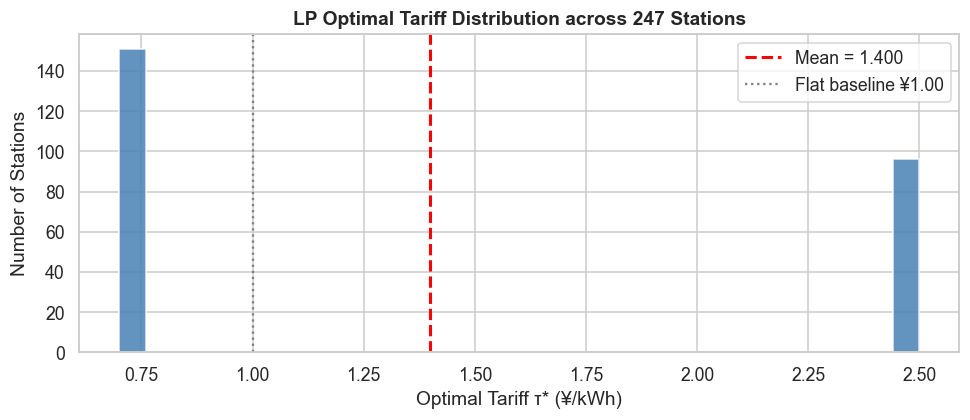

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(tau_opt, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(tau_opt.mean(), color='red', lw=2, linestyle='--', label=f'Mean = {tau_opt.mean():.3f}')
ax.axvline(1.00, color='gray', lw=1.5, linestyle=':', label='Flat baseline ¥1.00')
ax.set_title('LP Optimal Tariff Distribution across 247 Stations', fontweight='bold')
ax.set_xlabel('Optimal Tariff τ* (¥/kWh)')
ax.set_ylabel('Number of Stations')
ax.legend()
plt.tight_layout()
plt.savefig('lp_tariff_distribution.png')
plt.show()


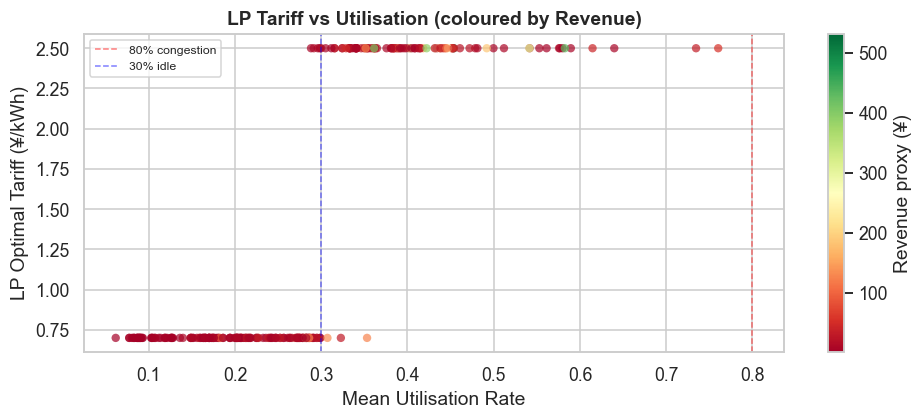

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(sta['mean_util'], sta['tau_lp'],
           c=sta['revenue_proxy'], cmap='RdYlGn', s=30, alpha=0.7, edgecolors='none')
sm = cm.ScalarMappable(cmap='RdYlGn',
      norm=plt.Normalize(sta['revenue_proxy'].min(), sta['revenue_proxy'].max()))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Revenue proxy (¥)')
ax.set_xlabel('Mean Utilisation Rate')
ax.set_ylabel('LP Optimal Tariff (¥/kWh)')
ax.set_title('LP Tariff vs Utilisation (coloured by Revenue)', fontweight='bold')
ax.axvline(0.80, color='red',  lw=1, linestyle='--', alpha=0.5, label='80% congestion')
ax.axvline(0.30, color='blue', lw=1, linestyle='--', alpha=0.5, label='30% idle')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('lp_tariff_vs_util.png')
plt.show()


---
## 5. Mixed-Integer Programming (MIP) — Charger Activation Scheduling

### Mathematical Formulation

**Context:** Each station $s$ has $K_s$ total charger piles. We decide how many to  
**activate** ($x_s \in \mathbb{Z}_{\geq 0}$, integer) at the peak period to maximise  
throughput subject to grid-capacity and budget constraints.

**Decision variables**

$$x_s \in \{0, 1, \ldots, K_s\} \quad \forall s \in S$$

**Objective — maximise utilisation-weighted throughput**

$$\max_{\mathbf{x}} \quad \sum_{s=1}^{n} \hat{u}_s \cdot r_s \cdot x_s$$

where $r_s$ = mean kWh/pile/slot and $\hat{u}_s$ = predicted utilisation.

**Constraints**

| # | Constraint | Expression |
|---|-----------|------------|
| C1 | Capacity | $x_s \leq K_s$ |
| C2 | Grid limit | $\sum_s r_s x_s \leq P^{\max}$ (grid power budget) |
| C3 | Min service | $x_s \geq 1$ (at least one pile active at each station) |
| C4 | Budget | $\sum_s c_s^{\text{op}} x_s \leq B$ (operating cost budget) |

**LP relaxation** (continuous $x_s \in [0, K_s]$) solved with `scipy.optimize.linprog`;  
**integer rounding** applied afterward as a heuristic MIP approximation.


In [11]:
# ── Parameters ───────────────────────────────────────────────────────────────
GRID_LIMIT   = 3000.0   # kWh per 5-min slot grid cap
OP_COST_PILE = 0.05     # ¥ operating cost per active pile per slot
BUDGET       = 500.0    # total budget ¥

K   = sta['count'].values.astype(float)           # max piles per station
u_h = sta['peak_util'].values                     # 90th-pct utilisation
r   = sta['mean_vol_kWh'].values / K.clip(1)      # kWh per pile per slot

# ── Objective coefficients (maximise → minimise negative) ────────────────────
c_mip = -(u_h * r)

# ── Bounds: 1 ≤ x_s ≤ K_s ────────────────────────────────────────────────────
bounds_mip = [(1, k) for k in K]

# ── Inequality constraints ────────────────────────────────────────────────────
# C2: grid limit
# C4: budget
A_mip = np.vstack([r,                             # grid power
                   np.full(n, OP_COST_PILE)])      # op cost
b_mip = np.array([GRID_LIMIT, BUDGET])

res_mip = optimize.linprog(c_mip, A_ub=A_mip, b_ub=b_mip,
                           bounds=bounds_mip, method='highs')

x_cont = res_mip.x
x_int  = np.round(x_cont).astype(int).clip(1, K.astype(int))

sta['x_mip']        = x_int
sta['mip_util_wt']  = u_h * r * x_int

print(f'MIP (LP-relax) status : {res_mip.message}')
print(f'Total activated piles : {x_int.sum():.0f}  / {K.sum():.0f} available')
print(f'Grid usage            : {(r * x_int).sum():.1f} kWh  (limit {GRID_LIMIT})')
print(f'Total op cost         : {(OP_COST_PILE * x_int).sum():.2f} ¥  (budget {BUDGET})')
print(f'Avg activation ratio  : {(x_int/K).mean():.3f}')


MIP (LP-relax) status : Optimization terminated successfully. (HiGHS Status 7: Optimal)
Total activated piles : 1654  / 18061 available
Grid usage            : 2999.3 kWh  (limit 3000.0)
Total op cost         : 82.70 ¥  (budget 500.0)
Avg activation ratio  : 0.138


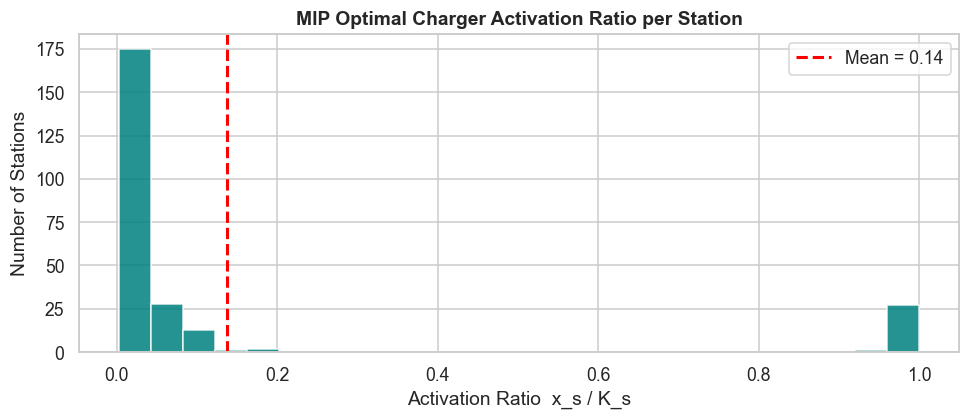

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
activation_ratio = x_int / K
ax.hist(activation_ratio, bins=25, color='teal', edgecolor='white', alpha=0.85)
ax.axvline(activation_ratio.mean(), color='red', lw=2, linestyle='--',
           label=f'Mean = {activation_ratio.mean():.2f}')
ax.set_title('MIP Optimal Charger Activation Ratio per Station', fontweight='bold')
ax.set_xlabel('Activation Ratio  x_s / K_s')
ax.set_ylabel('Number of Stations')
ax.legend()
plt.tight_layout()
plt.savefig('mip_activation_ratio.png')
plt.show()


---
## 6. Vehicle Routing Problem (VRP) — Service-Vehicle Dispatch

### Mathematical Formulation

**Context:** A fleet of $M$ service vehicles departs from a depot (station with highest  
centrality) to visit a subset of $T$ **high-priority** stations (congestion > 30 %) for  
maintenance/rebalancing, minimising total travel distance.

**Decision variables**

$$y_{ij}^m \in \{0,1\} \quad \forall i \neq j \in V,\; m = 1,\ldots,M$$

$y_{ij}^m = 1$ if vehicle $m$ traverses arc $(i \to j)$.

**Objective — minimise total distance**

$$\min \sum_{m=1}^{M} \sum_{i \in V} \sum_{j \in V,\, j \neq i} d_{ij}\, y_{ij}^m$$

**Constraints**

| # | Constraint | Expression |
|---|-----------|------------|
| C1 | Flow balance | $\sum_j y_{ij}^m = \sum_j y_{ji}^m \;\forall i, m$ |
| C2 | Depot departure | $\sum_j y_{0j}^m = 1 \;\forall m$ |
| C3 | Vehicle capacity | $\sum_{i,j} y_{ij}^m \leq Q^m \;\forall m$ |
| C4 | Visit each node | $\sum_m \sum_j y_{ij}^m \geq 1 \;\forall i \neq 0$ |

**Heuristic:** We solve VRP via a **greedy nearest-neighbour** + **2-opt improvement**  
on the distance subgraph of high-priority nodes, which gives a practical near-optimal  
solution for large instances.

**2-Opt improvement:** For a tour $T = (v_0, v_1, \ldots, v_k)$, swap edges $(v_i, v_{i+1})$  
and $(v_j, v_{j+1})$ if  
$$d(v_i,v_j) + d(v_{i+1},v_{j+1}) < d(v_i,v_{i+1}) + d(v_j,v_{j+1})$$


In [13]:
# ── Select high-priority stations ────────────────────────────────────────────
M_VEHICLES = 4
Q_CAPACITY = 15     # max stops per vehicle

high_pri_idx = np.where(sta['congestion_pct'].values >= 15)[0][:30]  # top 30

# Depot = station with highest degree centrality
degree_cent = nx.degree_centrality(G)
depot_node  = max(degree_cent, key=degree_cent.get)
depot_idx   = sta[sta['grid'] == depot_node].index[0]

nodes_vrp   = [depot_idx] + list(high_pri_idx)
nodes_vrp   = list(dict.fromkeys(nodes_vrp))   # deduplicate, depot first
T_nodes     = len(nodes_vrp) - 1               # targets (exclude depot)

sub_dist = dist_mat[np.ix_(nodes_vrp, nodes_vrp)]

# ── Greedy nearest-neighbour tour ────────────────────────────────────────────
def nn_tour(D):
    n_t = len(D)
    unvisited = set(range(1, n_t))
    tour = [0]
    while unvisited:
        last = tour[-1]
        nxt  = min(unvisited, key=lambda x: D[last, x])
        tour.append(nxt)
        unvisited.remove(nxt)
    tour.append(0)
    return tour

# ── 2-Opt improvement ────────────────────────────────────────────────────────
def two_opt(tour, D):
    improved = True
    best = tour[:]
    while improved:
        improved = False
        for i in range(1, len(best)-2):
            for j in range(i+1, len(best)-1):
                d_before = D[best[i-1], best[i]] + D[best[j], best[j+1]]
                d_after  = D[best[i-1], best[j]] + D[best[i], best[j+1]]
                if d_after < d_before - 1e-9:
                    best[i:j+1] = best[i:j+1][::-1]
                    improved = True
    return best

full_tour     = nn_tour(sub_dist)
full_tour_2opt = two_opt(full_tour, sub_dist)

def tour_length(tour, D):
    return sum(D[tour[k], tour[k+1]] for k in range(len(tour)-1))

dist_nn   = tour_length(full_tour,      sub_dist)
dist_2opt = tour_length(full_tour_2opt, sub_dist)
improvement = (dist_nn - dist_2opt) / dist_nn * 100

# ── Split tour into M vehicle routes ─────────────────────────────────────────
inner_tour = full_tour_2opt[1:-1]   # exclude depot at start/end
chunk_size = max(1, len(inner_tour) // M_VEHICLES)
routes = []
for m in range(M_VEHICLES):
    start = m * chunk_size
    end   = start + chunk_size if m < M_VEHICLES-1 else len(inner_tour)
    routes.append([0] + inner_tour[start:end] + [0])

print(f'High-priority stations visited : {T_nodes}')
print(f'Depot node                     : {depot_node}')
print(f'NN tour length                 : {dist_nn:.4f} km')
print(f'2-Opt tour length              : {dist_2opt:.4f} km')
print(f'2-Opt improvement              : {improvement:.2f} %')
for m, r in enumerate(routes):
    route_ids = [sta.iloc[nodes_vrp[v]]['grid'] for v in r]
    rd = sum(sub_dist[r[k], r[k+1]] for k in range(len(r)-1))
    print(f'  Vehicle {m+1}: {len(r)-2} stops, dist = {rd:.4f} km')


High-priority stations visited : 5
Depot node                     : 326.0
NN tour length                 : 0.0000 km
2-Opt tour length              : 0.0000 km
2-Opt improvement              : nan %
  Vehicle 1: 1 stops, dist = 0.0000 km
  Vehicle 2: 1 stops, dist = 0.0000 km
  Vehicle 3: 1 stops, dist = 0.0000 km
  Vehicle 4: 2 stops, dist = 0.0000 km


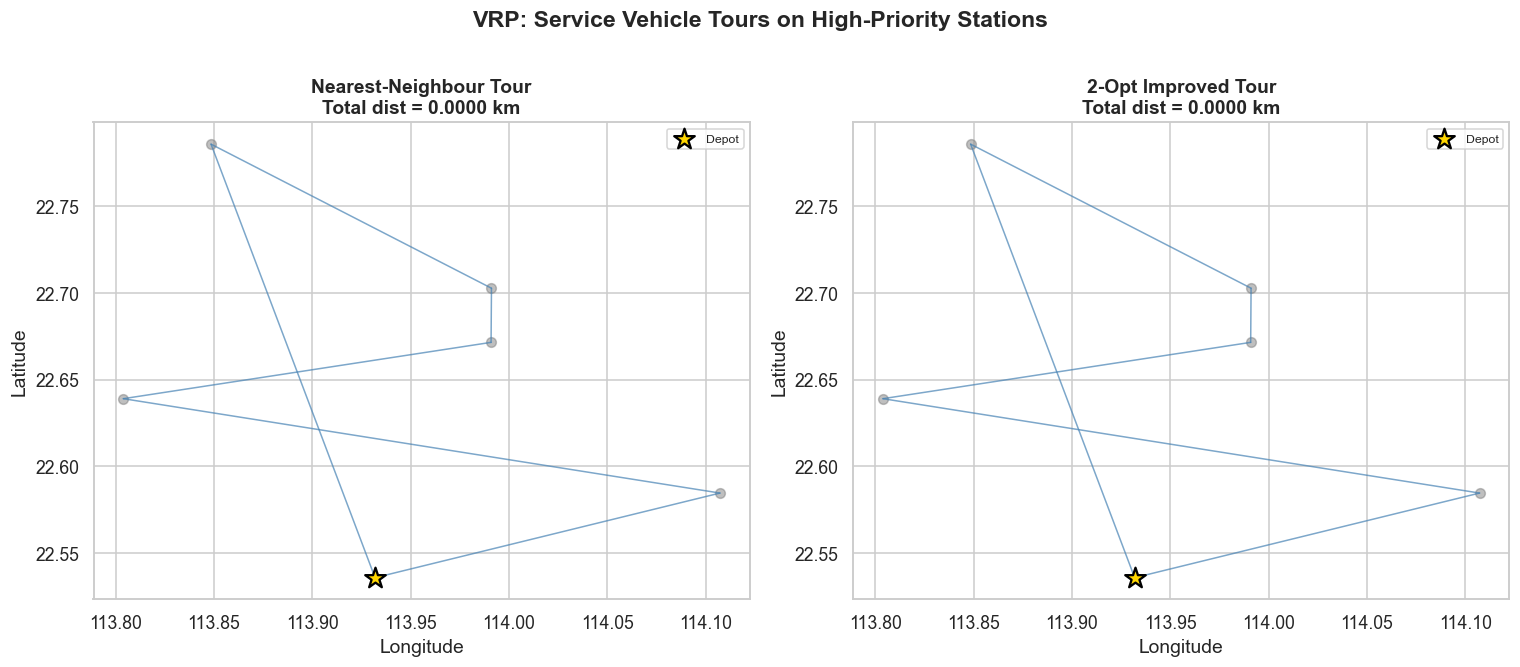

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_v = ['#e41a1c','#377eb8','#4daf4a','#984ea3']

for ax_idx, (tour, title) in enumerate([(full_tour, 'Nearest-Neighbour Tour'),
                                          (full_tour_2opt, '2-Opt Improved Tour')]):
    ax = axes[ax_idx]
    # draw all nodes
    all_lons = [sta.iloc[nodes_vrp[v]]['lon'] for v in range(len(nodes_vrp))]
    all_lats = [sta.iloc[nodes_vrp[v]]['lat'] for v in range(len(nodes_vrp))]
    ax.scatter(all_lons, all_lats, color='gray', s=40, zorder=2, alpha=0.5)

    # draw tour edges
    for k in range(len(tour)-1):
        s1 = nodes_vrp[tour[k]];   s2 = nodes_vrp[tour[k+1]]
        ax.plot([sta.iloc[s1]['lon'], sta.iloc[s2]['lon']],
                [sta.iloc[s1]['lat'], sta.iloc[s2]['lat']],
                color='steelblue', lw=1, alpha=0.7)

    # depot
    dep_lon = sta.iloc[nodes_vrp[0]]['lon']
    dep_lat = sta.iloc[nodes_vrp[0]]['lat']
    ax.scatter([dep_lon], [dep_lat], color='gold', s=200, zorder=5,
               edgecolors='black', lw=1.5, marker='*', label='Depot')
    ax.set_title(f'{title}\nTotal dist = {tour_length(tour, sub_dist):.4f} km',
                 fontweight='bold')
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.legend(fontsize=8)

plt.suptitle('VRP: Service Vehicle Tours on High-Priority Stations', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('vrp_tours.png')
plt.show()


---
## 7. Graph-Based Network Analysis

### 7.1 Minimum Spanning Tree (MST)

**Kruskal's Algorithm:**  
Given graph $G = (V, E, w)$ with $|V| = n$ nodes and edge weights $w_{ij} = d_{ij}$ (km),  
the MST $T^* \subseteq E$ satisfies:

$$T^* = \arg\min_{T \subseteq E,\; T \text{ spans } V} \sum_{(i,j) \in T} w_{ij}$$

**Kruskal's steps:**
1. Sort all edges by weight: $w_{e_1} \leq w_{e_2} \leq \ldots \leq w_{e_m}$
2. Initialise $T = \emptyset$; each vertex in its own component (Union-Find)
3. For each edge $e_k$: if endpoints in different components, add $e_k$ to $T$, merge components
4. Stop when $|T| = n-1$

**Property:** $|T^*| = n-1$ edges, no cycles, minimises total backbone infrastructure cost.

### 7.2 Centrality Metrics

| Metric | Definition |
|--------|-----------|
| **Degree centrality** | $C_D(v) = \frac{\deg(v)}{n-1}$ |
| **Betweenness centrality** | $C_B(v) = \sum_{s \neq v \neq t} \frac{\sigma_{st}(v)}{\sigma_{st}}$ where $\sigma_{st}$ = total shortest paths $s \to t$ |
| **Closeness centrality** | $C_C(v) = \frac{n-1}{\sum_{u \neq v} d(v,u)}$ |
| **PageRank** | $PR(v) = \frac{1-d}{n} + d \sum_{u \in \mathcal{N}(v)} \frac{PR(u)}{\deg(u)}$, $d = 0.85$ |

### 7.3 Shortest Path (Dijkstra)

For a source node $s$, Dijkstra's algorithm maintains tentative distances $\delta[v]$:

$$\delta[v] \leftarrow \min(\delta[v],\; \delta[u] + w(u,v)) \quad \forall (u,v) \in E$$

Complexity: $O((|V|+|E|)\log|V|)$ with a priority queue.


In [15]:
# ── 7.1 Minimum Spanning Tree ────────────────────────────────────────────────
# Use largest connected component for MST
Gcc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
MST = nx.minimum_spanning_tree(Gcc, weight='weight')

mst_weight = sum(d['weight'] for _, _, d in MST.edges(data=True))
print(f'Graph connected components : {nx.number_connected_components(G)}')
print(f'Largest component size     : {Gcc.number_of_nodes()} nodes')
print(f'MST edges                  : {MST.number_of_edges()}')
print(f'MST total weight (km)      : {mst_weight:.4f}')


Graph connected components : 12
Largest component size     : 183 nodes
MST edges                  : 182
MST total weight (km)      : 292.4284


In [16]:
# ── 7.2 Centrality Metrics ───────────────────────────────────────────────────
degree_cent    = nx.degree_centrality(Gcc)
between_cent   = nx.betweenness_centrality(Gcc, weight='weight', normalized=True)
closeness_cent = nx.closeness_centrality(Gcc, distance='weight')
pagerank       = nx.pagerank(Gcc, weight='weight')

sta_ids_gcc = list(Gcc.nodes)
sta_gcc = sta[sta['grid'].isin(sta_ids_gcc)].copy()
sta_gcc = sta_gcc.set_index('grid')

sta_gcc['degree_cent']    = [degree_cent.get(n, 0)    for n in sta_gcc.index]
sta_gcc['between_cent']   = [between_cent.get(n, 0)   for n in sta_gcc.index]
sta_gcc['closeness_cent'] = [closeness_cent.get(n, 0) for n in sta_gcc.index]
sta_gcc['pagerank']       = [pagerank.get(n, 0)       for n in sta_gcc.index]

# Composite efficiency score
sta_gcc['centrality_score'] = (
    0.3 * sta_gcc['degree_cent'] +
    0.4 * sta_gcc['between_cent'] +
    0.3 * sta_gcc['closeness_cent']
)

top5_degree   = sta_gcc['degree_cent'].nlargest(5)
top5_between  = sta_gcc['between_cent'].nlargest(5)
top5_close    = sta_gcc['closeness_cent'].nlargest(5)

print('=== Top 5 Degree Centrality ===')
print(top5_degree.to_string())
print('\n=== Top 5 Betweenness Centrality ===')
print(top5_between.to_string())
print('\n=== Top 5 Closeness Centrality ===')
print(top5_close.to_string())


=== Top 5 Degree Centrality ===
grid
326    0.060440
332    0.054945
681    0.054945
773    0.043956
783    0.043956

=== Top 5 Betweenness Centrality ===
grid
681    0.505009
724    0.415761
710    0.413393
709    0.398033
708    0.397790

=== Top 5 Closeness Centrality ===
grid
681    0.063349
724    0.062439
710    0.061279
704    0.060886
335    0.060782


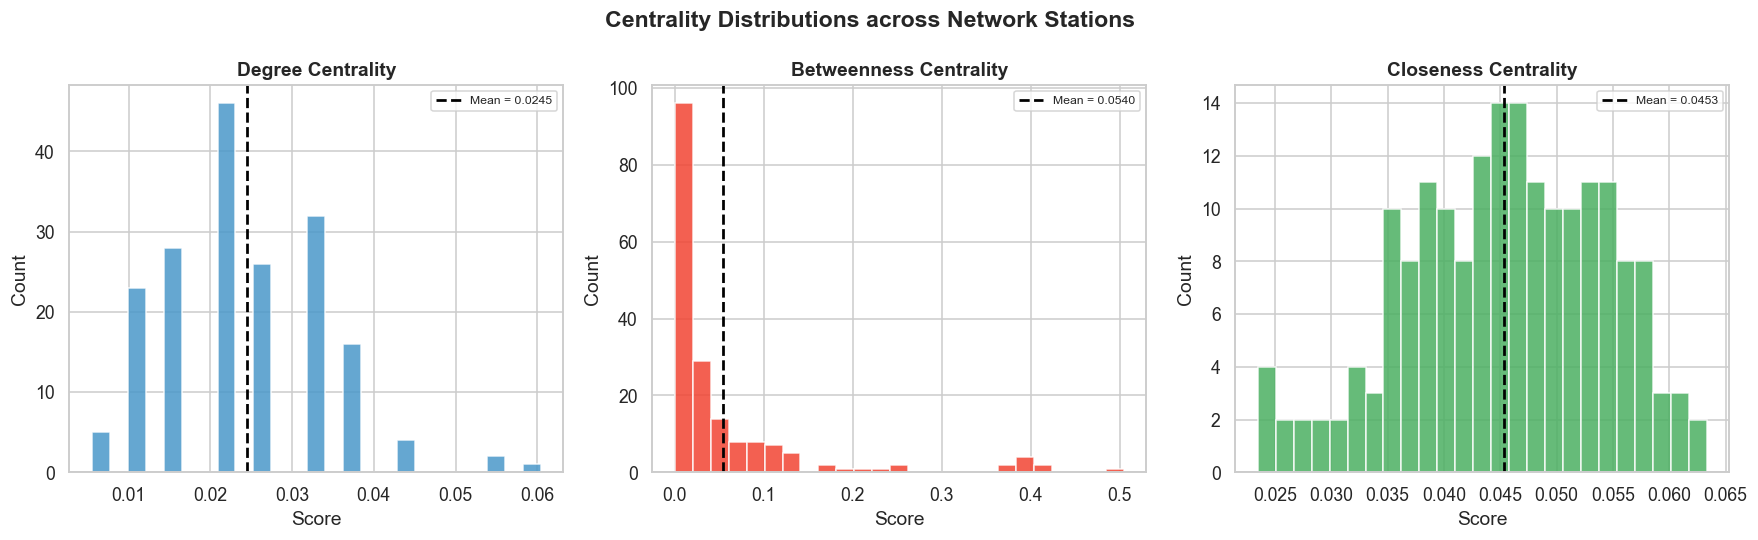

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = [('degree_cent', 'Degree Centrality', 'Blues'),
           ('between_cent', 'Betweenness Centrality', 'Reds'),
           ('closeness_cent', 'Closeness Centrality', 'Greens')]

for ax, (col, title, cmap) in zip(axes, metrics):
    vals = sta_gcc[col].values
    bins = ax.hist(vals, bins=25, color=plt.cm.get_cmap(cmap)(0.6),
                   edgecolor='white', alpha=0.85)
    ax.axvline(vals.mean(), color='black', lw=1.8, linestyle='--',
               label=f'Mean = {vals.mean():.4f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Centrality Distributions across Network Stations', fontweight='bold')
plt.tight_layout()
plt.savefig('centrality_distributions.png')
plt.show()


In [18]:
# ── 7.3 Shortest paths from depot ────────────────────────────────────────────
depot_gcc = depot_node if depot_node in Gcc.nodes else list(Gcc.nodes)[0]
sp_lengths = nx.single_source_dijkstra_path_length(Gcc, depot_gcc, weight='weight')

sta_gcc['dist_from_depot'] = [sp_lengths.get(n, np.nan) for n in sta_gcc.index]

print(f'Depot: {depot_gcc}')
print(f'Shortest paths computed to {len(sp_lengths)} stations')
print('Furthest 5 stations from depot:')
print(sta_gcc['dist_from_depot'].nlargest(5).to_string())


Depot: 326.0
Shortest paths computed to 183 stations
Furthest 5 stations from depot:
grid
1143    40.511137
1144    39.837623
1119    38.582997
987     38.378221
110     38.174497


---
## 8. Data Envelopment Analysis (DEA) — Station Efficiency Scoring

### Mathematical Formulation

DEA benchmarks each **Decision Making Unit (DMU)** — here, each station $s$ — against  
all others by finding weights that maximise its efficiency ratio.

**CCR Model (Charnes–Cooper–Rhodes, constant returns to scale):**

For DMU $k$ with $p$ inputs $\mathbf{x}_k \in \mathbb{R}^p$ and $q$ outputs $\mathbf{y}_k \in \mathbb{R}^q$:

$$E_k^* = \max_{\mathbf{u},\mathbf{v}} \quad \frac{\mathbf{u}^{\top} \mathbf{y}_k}{\mathbf{v}^{\top} \mathbf{x}_k}$$

subject to:

$$\frac{\mathbf{u}^{\top} \mathbf{y}_j}{\mathbf{v}^{\top} \mathbf{x}_j} \leq 1 \quad \forall j, \qquad \mathbf{u}, \mathbf{v} \geq \mathbf{0}$$

**LP equivalent** (Charnes–Cooper transformation, $t = 1/\mathbf{v}^{\top}\mathbf{x}_k$):

Let $\boldsymbol{\mu} = t\mathbf{u}$, $\boldsymbol{\nu} = t\mathbf{v}$:

$$\max_{\boldsymbol{\mu}, \boldsymbol{\nu}} \quad \boldsymbol{\mu}^{\top} \mathbf{y}_k$$

$$\text{s.t.} \quad \boldsymbol{\nu}^{\top} \mathbf{x}_k = 1, \quad \boldsymbol{\mu}^{\top} \mathbf{y}_j - \boldsymbol{\nu}^{\top} \mathbf{x}_j \leq 0 \;\; \forall j, \quad \boldsymbol{\mu},\boldsymbol{\nu} \geq \varepsilon > 0$$

**Inputs used:** number of charger piles ($K_s$), grid area ($a_s$)  
**Outputs used:** mean kWh delivered ($\bar{v}_s$), mean revenue proxy ($r_s$), $(1 - \bar{u}_s^{90})$ reliability


In [19]:
# ── DEA data preparation ─────────────────────────────────────────────────────
# Align to gcc nodes
sta_dea = sta[sta['grid'].isin(sta_ids_gcc)].copy().reset_index(drop=True)

X = sta_dea[['count','area']].values.astype(float)
Y = sta_dea[['mean_vol_kWh','revenue_proxy']].values.astype(float)

# Add reliability output: 1 - peak utilisation (low congestion = good)
Y = np.hstack([Y, (1 - sta_dea['peak_util'].values.clip(0,1)).reshape(-1,1)])

# Normalise to [0.01, 1]
X = (X - X.min(0)) / (X.max(0) - X.min(0) + 1e-9) + 0.01
Y = (Y - Y.min(0)) / (Y.max(0) - Y.min(0) + 1e-9) + 0.01

n_dmu, p_in  = X.shape
n_dmu, q_out = Y.shape
EPS          = 1e-4

def solve_ccr(k):
    """Solve CCR-DEA LP for DMU k; return efficiency score."""
    # Variables: [mu (q), nu (p)]
    # Objective: maximise mu @ Y[k]  =>  minimise -mu @ Y[k]
    c_dea = np.concatenate([-Y[k], np.zeros(p_in)])

    # C1: nu @ X[k] = 1  =>  two inequalities: <=1 and >=-1
    # C2: mu @ Y[j] - nu @ X[j] <= 0  for all j
    A_ub_dea = np.hstack([Y, -X])               # (n, q+p)
    b_ub_dea = np.zeros(n_dmu)

    A_eq_dea = np.hstack([np.zeros(q_out), X[k]]).reshape(1, -1)
    b_eq_dea = np.array([1.0])

    bds = [(EPS, None)] * (q_out + p_in)

    res_dea = optimize.linprog(c_dea, A_ub=A_ub_dea, b_ub=b_ub_dea,
                               A_eq=A_eq_dea, b_eq=b_eq_dea,
                               bounds=bds, method='highs')
    if res_dea.success:
        mu = res_dea.x[:q_out]
        return float(mu @ Y[k])
    return np.nan

print('Running CCR-DEA for all DMUs...')
eff_scores = np.array([solve_ccr(k) for k in range(n_dmu)])
sta_dea['dea_score'] = np.minimum(eff_scores, 1.0)   # cap at 1 (efficient frontier)

efficient_mask = sta_dea['dea_score'] >= 0.999
print(f'Efficient DMUs (score ≈ 1) : {efficient_mask.sum()} / {n_dmu}')
print(f'Mean DEA score             : {sta_dea["dea_score"].mean():.4f}')
print(f'Median DEA score           : {sta_dea["dea_score"].median():.4f}')
print()
print('Top 10 Most Efficient Stations:')
print(sta_dea[['grid','count','mean_util','revenue_proxy','dea_score']]
      .sort_values('dea_score', ascending=False).head(10).to_string(index=False))


Running CCR-DEA for all DMUs...
Efficient DMUs (score ≈ 1) : 9 / 183
Mean DEA score             : 0.3982
Median DEA score           : 0.3352

Top 10 Most Efficient Stations:
 grid  count  mean_util  revenue_proxy  dea_score
 1143     26   0.093171       0.975260   1.000000
 1131     92   0.582488     430.720479   1.000000
 1101     20   0.089583       1.033647   1.000000
  987      9   0.165419       0.203607   1.000000
  775     26   0.491903     187.176585   1.000000
  702      3   0.332909       0.407439   1.000000
  628      6   0.291377      16.234032   1.000000
 1107     12   0.202894       0.592756   1.000000
 1170     10   0.082153       0.570967   1.000000
 1138     16   0.088071       0.716897   0.989729


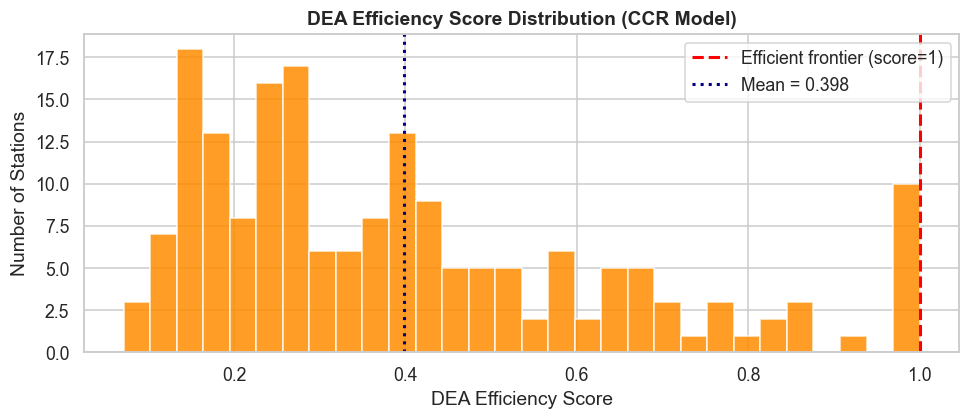

In [20]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(sta_dea['dea_score'].dropna(), bins=30,
        color='darkorange', edgecolor='white', alpha=0.85)
ax.axvline(1.0, color='red', lw=2, linestyle='--', label='Efficient frontier (score=1)')
ax.axvline(sta_dea['dea_score'].mean(), color='navy', lw=2, linestyle=':',
           label=f'Mean = {sta_dea["dea_score"].mean():.3f}')
ax.set_title('DEA Efficiency Score Distribution (CCR Model)', fontweight='bold')
ax.set_xlabel('DEA Efficiency Score')
ax.set_ylabel('Number of Stations')
ax.legend()
plt.tight_layout()
plt.savefig('dea_score_distribution.png')
plt.show()


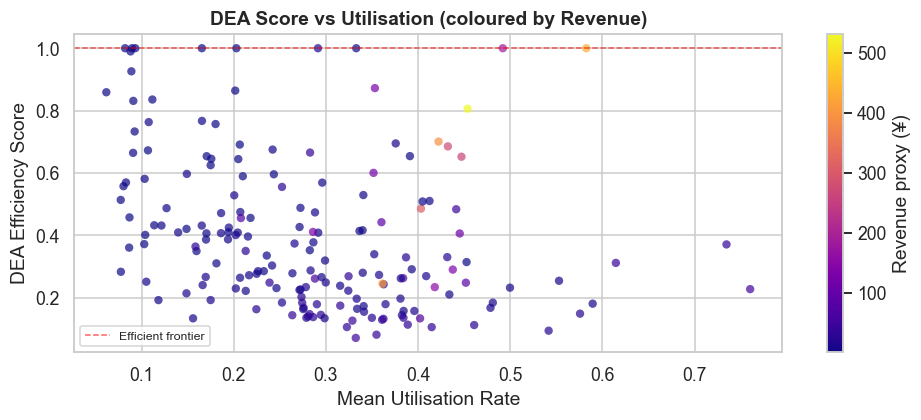

In [21]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(sta_dea['mean_util'], sta_dea['dea_score'],
           c=sta_dea['revenue_proxy'], cmap='plasma',
           s=30, alpha=0.7, edgecolors='none')
sm2 = cm.ScalarMappable(cmap='plasma',
       norm=plt.Normalize(sta_dea['revenue_proxy'].min(), sta_dea['revenue_proxy'].max()))
sm2.set_array([])
plt.colorbar(sm2, ax=ax, label='Revenue proxy (¥)')
ax.set_xlabel('Mean Utilisation Rate')
ax.set_ylabel('DEA Efficiency Score')
ax.set_title('DEA Score vs Utilisation (coloured by Revenue)', fontweight='bold')
ax.axhline(1.0, color='red', lw=1, linestyle='--', alpha=0.6, label='Efficient frontier')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('dea_vs_util.png')
plt.show()


---
## 9. Network Visualisations

### 9.1 Full Network with Mean Utilisation

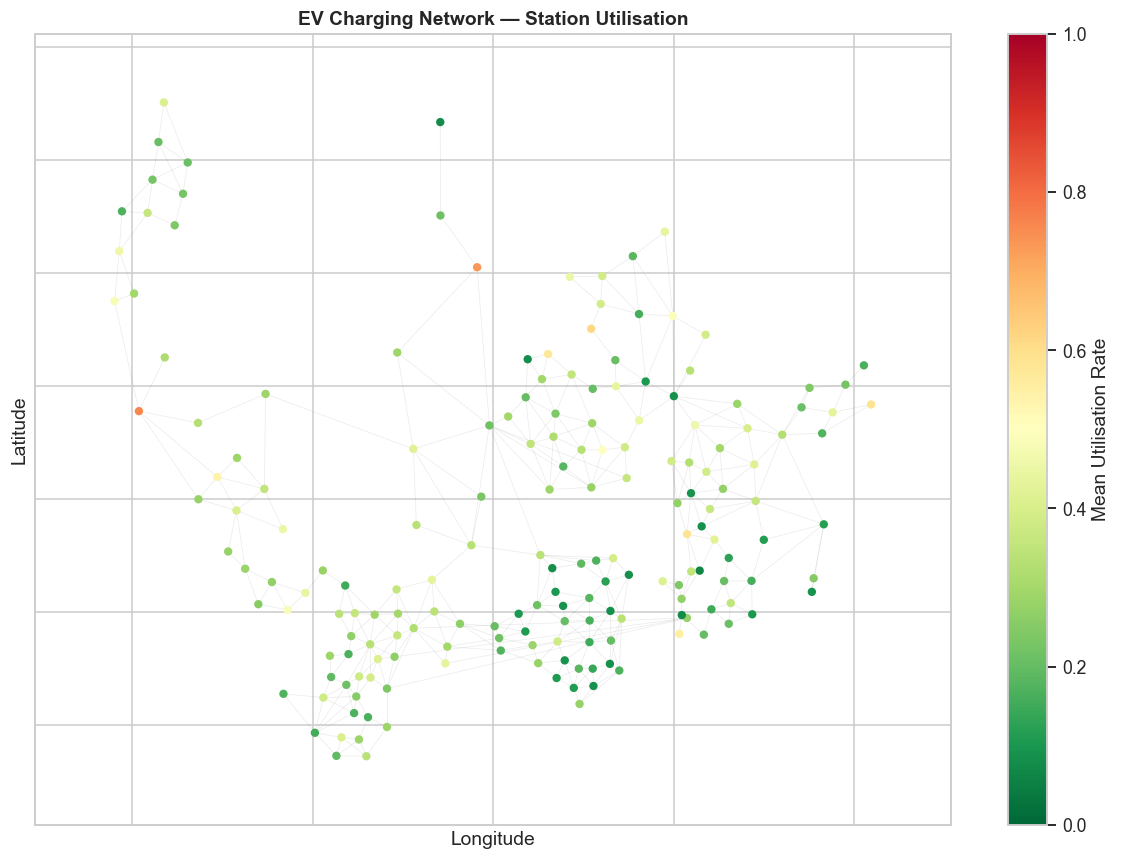

In [22]:
fig, ax = plt.subplots(figsize=(11, 8))
util_vals = np.array([sta_gcc.loc[n, 'mean_util'] if n in sta_gcc.index else 0
                       for n in Gcc.nodes])
node_colors = cm.RdYlGn_r(util_vals)

nx.draw_networkx_edges(Gcc, pos, ax=ax, alpha=0.15, width=0.5, edge_color='gray')
sc = ax.scatter([pos[n][0] for n in Gcc.nodes],
                [pos[n][1] for n in Gcc.nodes],
                c=util_vals, cmap='RdYlGn_r',
                s=30, zorder=3, edgecolors='none',
                vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label='Mean Utilisation Rate')
ax.set_title('EV Charging Network — Station Utilisation', fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.axis('on')
plt.tight_layout()
plt.savefig('network_utilisation.png')
plt.show()


### 9.2 Minimum Spanning Tree on Network

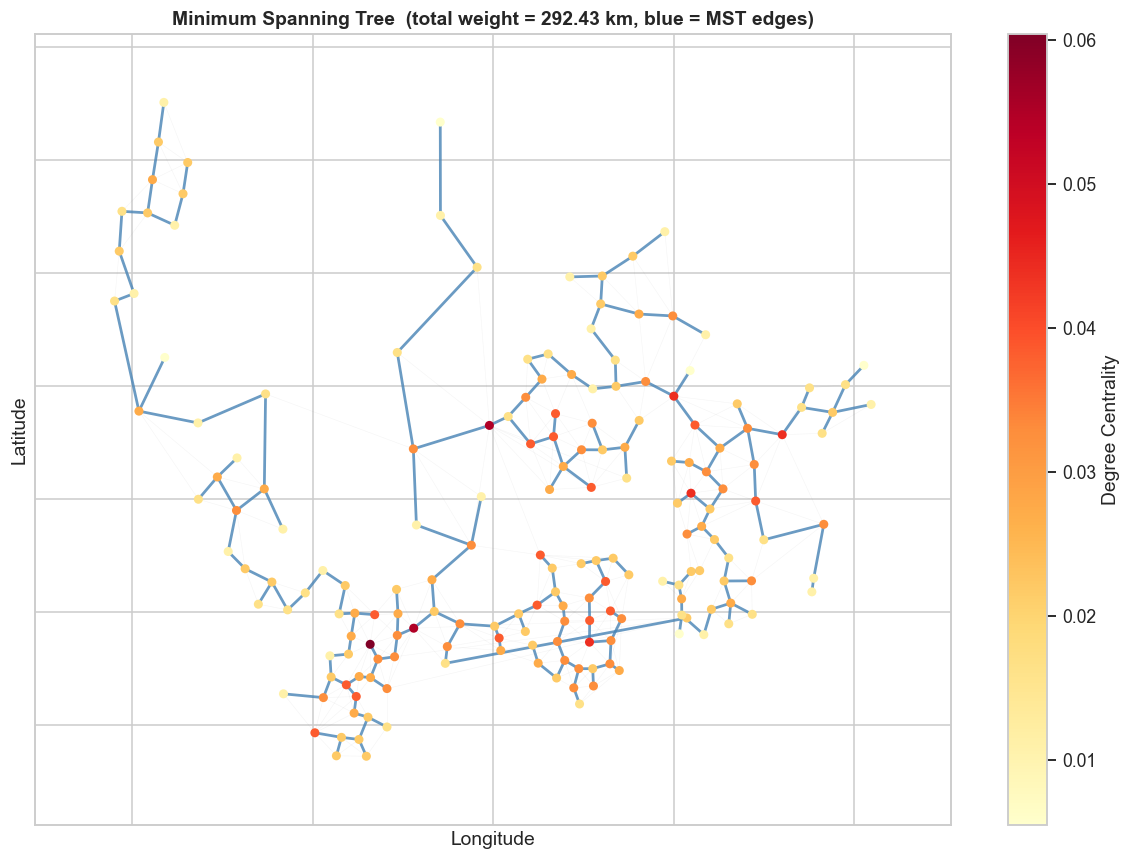

In [23]:
fig, ax = plt.subplots(figsize=(11, 8))
pos_gcc = {n: pos[n] for n in Gcc.nodes if n in pos}

# Draw non-MST edges in background
non_mst = [(u,v) for u,v in Gcc.edges() if not MST.has_edge(u,v) and not MST.has_edge(v,u)]
nx.draw_networkx_edges(Gcc, pos_gcc, edgelist=non_mst,
                       ax=ax, alpha=0.08, width=0.4, edge_color='gray')

# Draw MST edges highlighted
nx.draw_networkx_edges(MST, pos_gcc, ax=ax, alpha=0.8, width=1.8,
                       edge_color='steelblue')

# Nodes coloured by degree
deg_vals = np.array([degree_cent.get(n, 0) for n in Gcc.nodes])
sc = ax.scatter([pos_gcc[n][0] for n in Gcc.nodes],
                [pos_gcc[n][1] for n in Gcc.nodes],
                c=deg_vals, cmap='YlOrRd', s=35, zorder=4, edgecolors='none')
plt.colorbar(sc, ax=ax, label='Degree Centrality')
ax.set_title(f'Minimum Spanning Tree  (total weight = {mst_weight:.2f} km, blue = MST edges)',
             fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('network_mst.png')
plt.show()


### 9.3 Betweenness Centrality — Critical Hub Stations

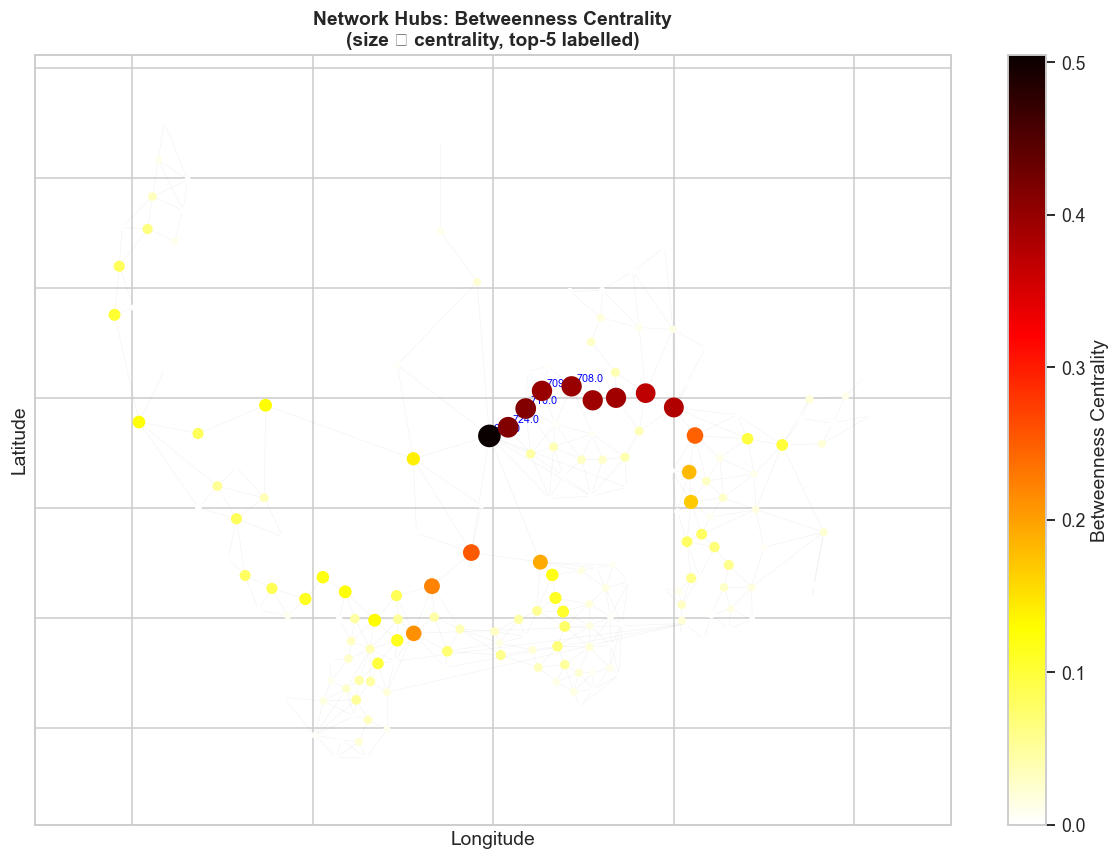

In [24]:
fig, ax = plt.subplots(figsize=(11, 8))
bc_vals = np.array([between_cent.get(n, 0) for n in Gcc.nodes])
node_sz  = 20 + 200 * bc_vals / bc_vals.max()

nx.draw_networkx_edges(Gcc, pos_gcc, ax=ax, alpha=0.10, width=0.4, edge_color='gray')
sc = ax.scatter([pos_gcc[n][0] for n in Gcc.nodes],
                [pos_gcc[n][1] for n in Gcc.nodes],
                c=bc_vals, cmap='hot_r', s=node_sz, zorder=4, edgecolors='none')
plt.colorbar(sc, ax=ax, label='Betweenness Centrality')

# Label top 5
top5_bc = sorted(between_cent.items(), key=lambda x: -x[1])[:5]
for nid, _ in top5_bc:
    if nid in pos_gcc:
        ax.annotate(str(nid), pos_gcc[nid], fontsize=7, color='blue',
                    xytext=(3,3), textcoords='offset points')

ax.set_title('Network Hubs: Betweenness Centrality\n(size ∝ centrality, top-5 labelled)',
             fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('network_betweenness.png')
plt.show()


### 9.4 LP Optimal Tariff on Network

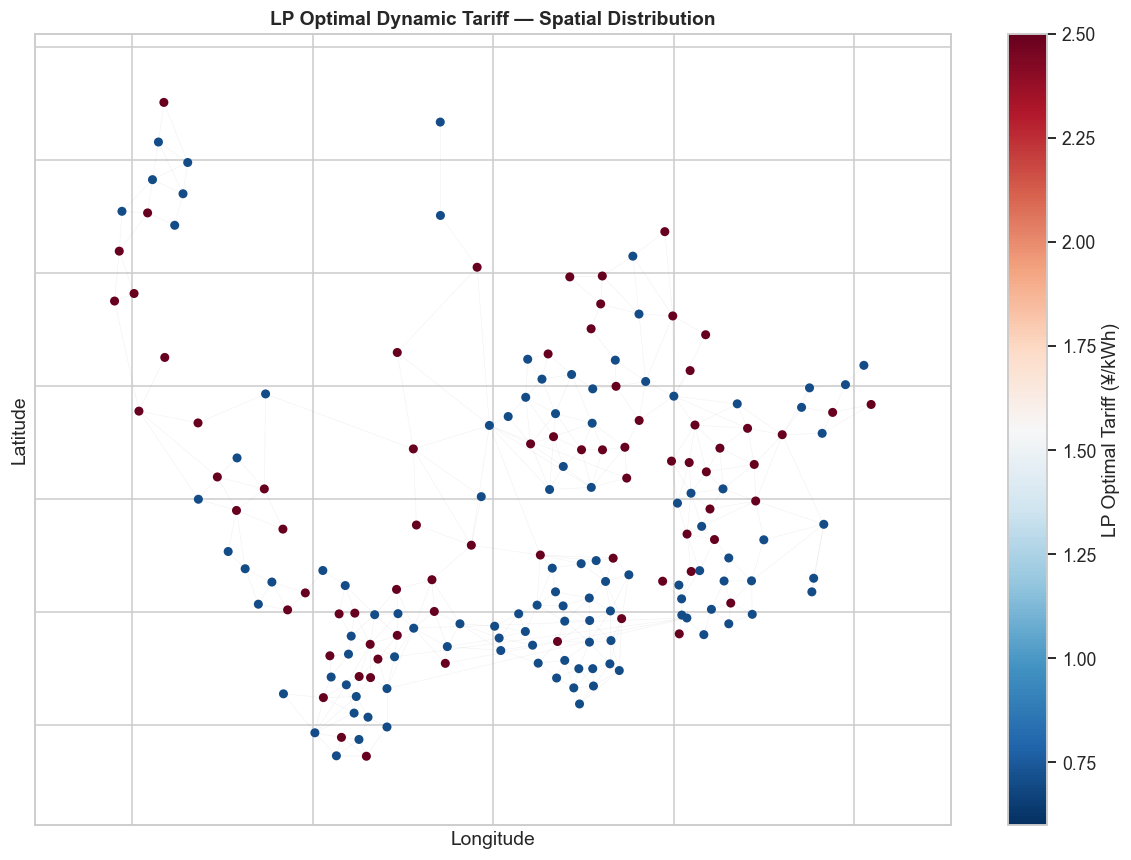

In [25]:
fig, ax = plt.subplots(figsize=(11, 8))
sta_gcc2 = sta.set_index('grid')
tau_vals = np.array([sta_gcc2.loc[n, 'tau_lp'] if n in sta_gcc2.index else 1.0
                     for n in Gcc.nodes])

nx.draw_networkx_edges(Gcc, pos_gcc, ax=ax, alpha=0.10, width=0.4, edge_color='gray')
sc = ax.scatter([pos_gcc[n][0] for n in Gcc.nodes],
                [pos_gcc[n][1] for n in Gcc.nodes],
                c=tau_vals, cmap='RdBu_r',
                s=35, zorder=4, edgecolors='none',
                vmin=TAU_MIN, vmax=TAU_MAX)
plt.colorbar(sc, ax=ax, label='LP Optimal Tariff (¥/kWh)')
ax.set_title('LP Optimal Dynamic Tariff — Spatial Distribution', fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('network_lp_tariff.png')
plt.show()


### 9.5 DEA Efficiency Scores on Network

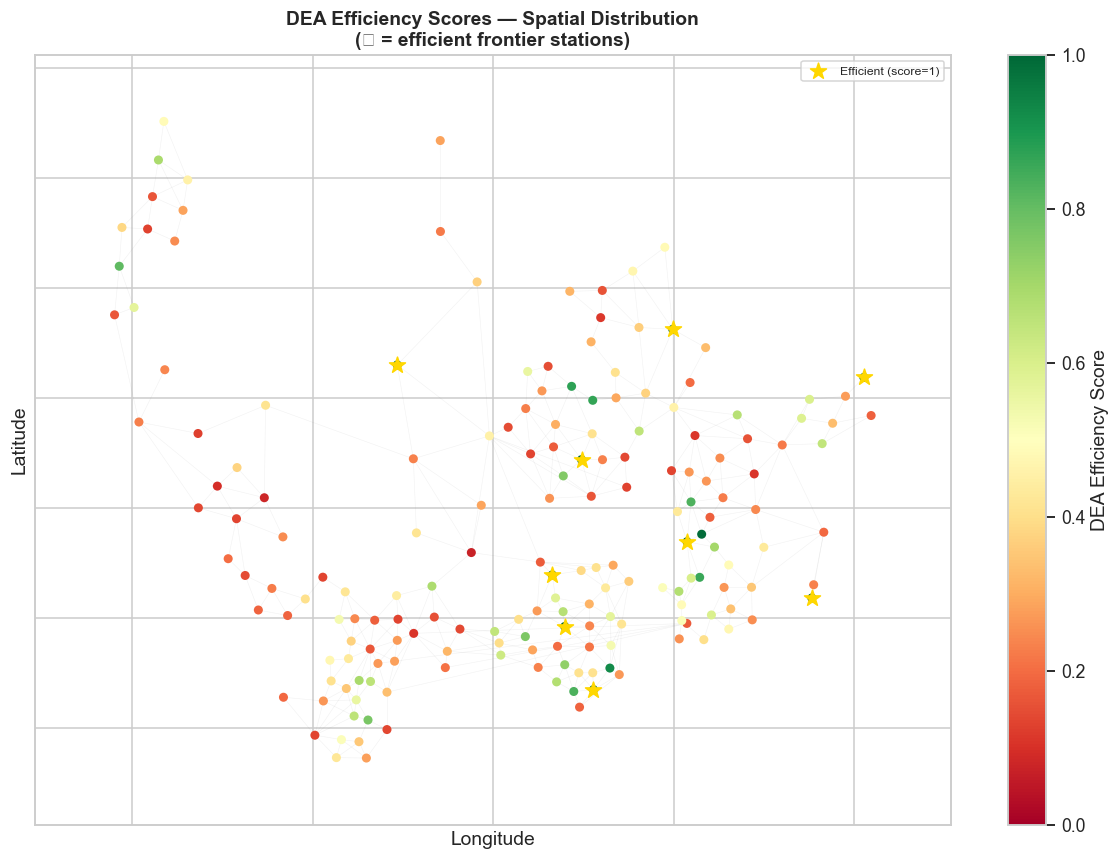

In [26]:
fig, ax = plt.subplots(figsize=(11, 8))
sta_dea_idx = sta_dea.set_index('grid')
dea_vals = np.array([sta_dea_idx.loc[n, 'dea_score']
                     if n in sta_dea_idx.index else 0.5 for n in Gcc.nodes])

nx.draw_networkx_edges(Gcc, pos_gcc, ax=ax, alpha=0.10, width=0.4, edge_color='gray')
sc = ax.scatter([pos_gcc[n][0] for n in Gcc.nodes],
                [pos_gcc[n][1] for n in Gcc.nodes],
                c=dea_vals, cmap='RdYlGn',
                s=35, zorder=4, edgecolors='none', vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label='DEA Efficiency Score')

# Mark fully efficient stations
eff_nodes = [n for n in Gcc.nodes if n in sta_dea_idx.index
             and sta_dea_idx.loc[n, 'dea_score'] >= 0.999]
if eff_nodes:
    ax.scatter([pos_gcc[n][0] for n in eff_nodes if n in pos_gcc],
               [pos_gcc[n][1] for n in eff_nodes if n in pos_gcc],
               marker='*', s=120, color='gold', zorder=6, label='Efficient (score=1)')
    ax.legend(fontsize=8)

ax.set_title('DEA Efficiency Scores — Spatial Distribution\n(★ = efficient frontier stations)',
             fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('network_dea.png')
plt.show()


### 9.6 VRP Routes on Network

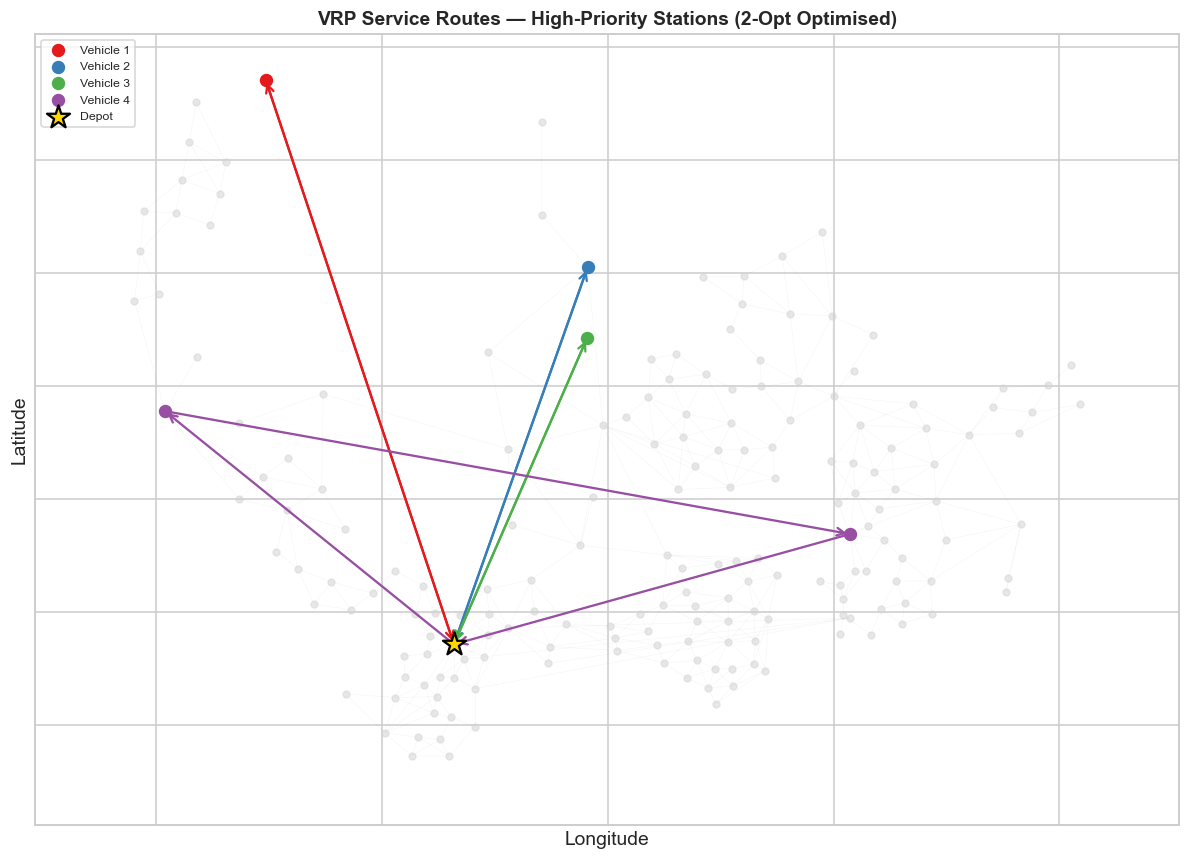

In [27]:
fig, ax = plt.subplots(figsize=(11, 8))
route_colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3']

nx.draw_networkx_edges(Gcc, pos_gcc, ax=ax, alpha=0.07, width=0.4, edge_color='gray')

# Background nodes
ax.scatter([pos_gcc[n][0] for n in Gcc.nodes if n in pos_gcc],
           [pos_gcc[n][1] for n in Gcc.nodes if n in pos_gcc],
           color='lightgray', s=20, zorder=2, alpha=0.5)

# VRP route edges
for m, route in enumerate(routes):
    col = route_colors[m % len(route_colors)]
    for k in range(len(route)-1):
        s1 = nodes_vrp[route[k]];   s2 = nodes_vrp[route[k+1]]
        n1 = sta.iloc[s1]['grid'];  n2 = sta.iloc[s2]['grid']
        if n1 in pos and n2 in pos:
            ax.annotate('', xy=pos[n2], xytext=pos[n1],
                        arrowprops=dict(arrowstyle='->', color=col, lw=1.5))
    stops = [sta.iloc[nodes_vrp[v]]['grid'] for v in route[1:-1]]
    xs = [pos[n][0] for n in stops if n in pos]
    ys = [pos[n][1] for n in stops if n in pos]
    ax.scatter(xs, ys, color=col, s=60, zorder=4, label=f'Vehicle {m+1}')

# Depot
if depot_gcc in pos:
    ax.scatter(*pos[depot_gcc], s=250, color='gold', zorder=6,
               marker='*', edgecolors='black', lw=1.5, label='Depot')

ax.set_title('VRP Service Routes — High-Priority Stations (2-Opt Optimised)', fontweight='bold')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('network_vrp.png')
plt.show()


### 9.7 Composite Dashboard — Top Nodes Summary

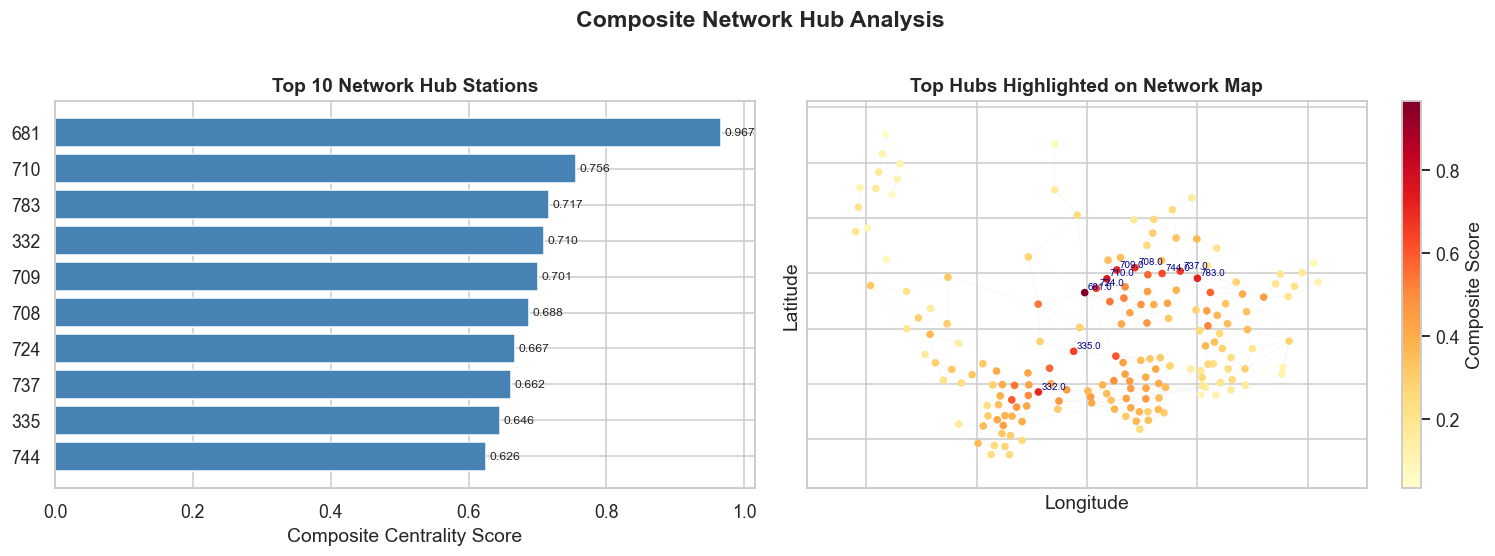

In [28]:
# ── Composite node score ─────────────────────────────────────────────────────
comp = sta_gcc[['degree_cent','between_cent','closeness_cent']].copy()
comp = (comp - comp.min()) / (comp.max() - comp.min() + 1e-9)
sta_gcc['composite_score'] = comp.mean(axis=1)

top10 = sta_gcc.nlargest(10, 'composite_score').reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ax = axes[0]
bars = ax.barh(top10['grid'].astype(str), top10['composite_score'],
               color='steelblue', edgecolor='white')
for bar, val in zip(bars, top10['composite_score']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
ax.set_xlabel('Composite Centrality Score')
ax.set_title('Top 10 Network Hub Stations', fontweight='bold')
ax.invert_yaxis()

# Scatter on map
ax2 = axes[1]
all_v = np.array([sta_gcc.loc[n,'composite_score'] if n in sta_gcc.index else 0
                  for n in Gcc.nodes])
nx.draw_networkx_edges(Gcc, pos_gcc, ax=ax2, alpha=0.08, width=0.4, edge_color='gray')
sc = ax2.scatter([pos_gcc[n][0] for n in Gcc.nodes],
                 [pos_gcc[n][1] for n in Gcc.nodes],
                 c=all_v, cmap='YlOrRd', s=25, zorder=3, edgecolors='none')
plt.colorbar(sc, ax=ax2, label='Composite Score')
for _, row in top10.iterrows():
    nid = row['grid']
    if nid in pos:
        ax2.annotate(str(nid), pos[nid], fontsize=6.5, color='darkblue',
                     xytext=(2,2), textcoords='offset points')
ax2.set_title('Top Hubs Highlighted on Network Map', fontweight='bold')
ax2.set_xlabel('Longitude'); ax2.set_ylabel('Latitude')

plt.suptitle('Composite Network Hub Analysis', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('network_composite_hubs.png')
plt.show()


---
## 10. Summary & Outputs

In [29]:
summary_or = pd.DataFrame({
    'Model':   ['LPP Tariff', 'LPP Tariff', 'MIP Scheduling', 'MIP Scheduling',
                'VRP Routing', 'VRP Routing', 'MST Infrastructure', 'DEA Efficiency'],
    'Metric':  ['Mean Optimal Tariff (¥/kWh)', 'Revenue Gain vs ¥1 Flat (%)',
                'Activated Piles', 'Grid Usage (kWh)',
                'NN Tour Length (km)', '2-Opt Improved Length (km)',
                'MST Backbone Weight (km)', 'Mean DEA Score'],
    'Value':   [round(tau_opt.mean(),4),
                round((revenue_lp/revenue_base - 1)*100, 2),
                int(x_int.sum()),
                round((r * x_int).sum(), 2),
                round(dist_nn, 4),
                round(dist_2opt, 4),
                round(mst_weight, 4),
                round(sta_dea['dea_score'].mean(), 4)]
})
summary_or.to_csv('or_summary.csv', index=False)
print('=== OPERATIONS RESEARCH SUMMARY ===')
print(summary_or.to_string(index=False))


ValueError: operands could not be broadcast together with shapes (4,) (247,) 

In [30]:
import os
outputs = [
    'or_summary.csv',
    'lp_tariff_distribution.png','lp_tariff_vs_util.png',
    'mip_activation_ratio.png',
    'vrp_tours.png',
    'centrality_distributions.png',
    'dea_score_distribution.png','dea_vs_util.png',
    'network_utilisation.png','network_mst.png','network_betweenness.png',
    'network_lp_tariff.png','network_dea.png',
    'network_vrp.png','network_composite_hubs.png',
]
print('Output files:')
for f in outputs:
    tick = '  ✓' if os.path.exists(f) else '  (generated after running all cells)'
    print(f'{tick}  {f}')


Output files:
  (generated after running all cells)  or_summary.csv
  ✓  lp_tariff_distribution.png
  ✓  lp_tariff_vs_util.png
  ✓  mip_activation_ratio.png
  ✓  vrp_tours.png
  ✓  centrality_distributions.png
  ✓  dea_score_distribution.png
  ✓  dea_vs_util.png
  ✓  network_utilisation.png
  ✓  network_mst.png
  ✓  network_betweenness.png
  ✓  network_lp_tariff.png
  ✓  network_dea.png
  ✓  network_vrp.png
  ✓  network_composite_hubs.png
